---
title: "Does the Koruna Actually Move Independently of the Euro?"
author: "Tomáš Trnka"
date: "2026-07-28"
categories: [data-analysis, finance, macro, czk]
format:
  html:
    toc: true
    code-fold: true
    code-tools: true
execute:
  warning: false
  message: false
---

## Background

One argument for Czechia keeping the koruna instead of adopting the euro is that it gives
the central bank ([ČNB](https://www.cnb.cz)) an extra lever: it can let the exchange rate
move (or actively manage it) instead of only setting interest rates. My prior going in was
skeptical of how much this actually matters in practice — the Czech economy is so tightly
integrated with the eurozone that I expected CZK/EUR to be close to a de facto peg, in which
case CZK/USD would just be a scaled copy of EUR/USD and the "extra lever" would be mostly
theoretical.

This post checks that directly using ~20.5 years of daily data (2006–2026). The plan:

1. Confirm the three rates — CZK/EUR, EUR/USD, CZK/USD — are mutually consistent (no free
   lunch sitting in the market).
2. Zoom out to the long-run levels.
3. Measure *how tightly* CZK/EUR actually tracks vs. how volatile EUR/USD is on its own,
   using rolling volatility and rolling correlation rather than eyeballing a chart.
4. Zoom into the two episodes where Czech-specific monetary policy was most active — the
   2013–2017 exchange-rate floor and the 2022 war/rate-hiking shock — to see whether the
   koruna actually decoupled from the euro during exactly those windows.

In [1]:
#| label: setup
#| echo: false

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

EVENTS = [
    ('2008-09-01', '2009-03-31', 'Global financial crisis'),
    ('2013-11-07', '2017-04-06', 'ČNB EUR/CZK ≥ 27 floor'),
    ('2020-02-15', '2020-06-30', 'COVID crash'),
    ('2022-02-24', '2022-12-31', 'War in Ukraine / ČNB hiking to 7%'),
]

def shade_events(ax, label=True):
    for start, end, name in EVENTS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='grey', alpha=0.12)


## Data

Two independent sources, on purpose:

- **[ČNB](https://www.cnb.cz) daily fixing** — CZK per 1 EUR and CZK per 1 USD, both fixed
  directly by the Czech National Bank each business day. Bulk yearly files, e.g.
  `.../rok.txt?rok=2024`.
- **[Frankfurter](https://frankfurter.dev) (ECB reference rates)** — the standard EUR/USD
  market quote (USD per 1 EUR), published by the ECB, completely independent of ČNB.

If I derived all three rates from a single source (e.g. computing CZK/USD as
CZK/EUR ÷ EUR/USD from ECB data alone), the "triangle" would be consistent *by construction*
and checking it would prove nothing. Combining ČNB's own CZK/USD fixing with ČNB's CZK/EUR
and the ECB's EUR/USD gives three genuinely independent quotes, so checking whether they
agree is an actual test. `fetch_data.py` in this directory has the fetch code.

The triangular identity, given how each series is defined:

$$\text{CZK per EUR} = \text{CZK per USD} \times \text{USD per EUR}$$

so the *implied* CZK/USD from the other two legs is `czk_per_eur / usd_per_eur`.

One naming note used throughout the rest of this notebook: for the charts I invert the raw
ECB quote to **EUR per 1 USD** (`eur_per_usd = 1 / usd_per_eur`), so it's oriented the same
way as CZK per USD — both fall when the dollar weakens and rise when it strengthens. I keep
calling it "EUR/USD" for readability, but it's the *mirror* of the familiar market quote
(which is USD per EUR); charts are labelled "(inverted)" as a reminder, and any specific
price levels quoted in the text give the familiar standard-quote number alongside it.

In [2]:
#| label: load-data
#| code-fold: true
#| code-summary: "Load, merge, and derive the triangular quantities"

cnb = pd.read_csv('data/cnb_czk_fixing.csv', parse_dates=['date'])
ecb = pd.read_csv('data/ecb_eur_usd.csv', parse_dates=['date'])

df = pd.merge(cnb, ecb, on='date', how='inner').sort_values('date').reset_index(drop=True)
df['eur_per_usd'] = 1 / df['usd_per_eur']

# Implied CZK/USD from the other two independent legs, vs. ČNB's own quoted CZK/USD
df['czk_per_usd_implied'] = df['czk_per_eur'] / df['usd_per_eur']
df['deviation_bps'] = (df['czk_per_usd'] / df['czk_per_usd_implied'] - 1) * 1e4

for leg in ['czk_per_eur', 'czk_per_usd', 'eur_per_usd']:
    df[f'lret_{leg}'] = np.log(df[leg]).diff()

print(f'Rows            : {len(df):,}')
print(f'Date range      : {df["date"].min().date()} -> {df["date"].max().date()}')
print(f'Deviation (bps) : mean {df["deviation_bps"].mean():.2f}, std {df["deviation_bps"].std():.2f}, '
      f'max abs {df["deviation_bps"].abs().max():.1f}')


Rows            : 5,162
Date range      : 2006-01-02 -> 2026-07-27
Deviation (bps) : mean -0.31, std 2.39, max abs 41.8


## Is the triangle even consistent?

Before comparing the three rates to each other in any interesting way, it's worth checking
the boring thing first: does ČNB's own quoted CZK/USD actually match what you'd get by going
CZK → EUR → USD through the other two independently-sourced legs? In liquid FX markets this
is enforced by **triangular arbitrage** — if a bank's quoted cross rate strayed meaningfully
from the implied cross rate, traders would exploit the gap in three trades until it closed.
So I'd expect the deviation to be tiny and mostly noise from the two institutions fixing
their rates at slightly different times of day (ČNB fixes around 14:30 CET; the ECB
reference rate is set around 16:00 CET).

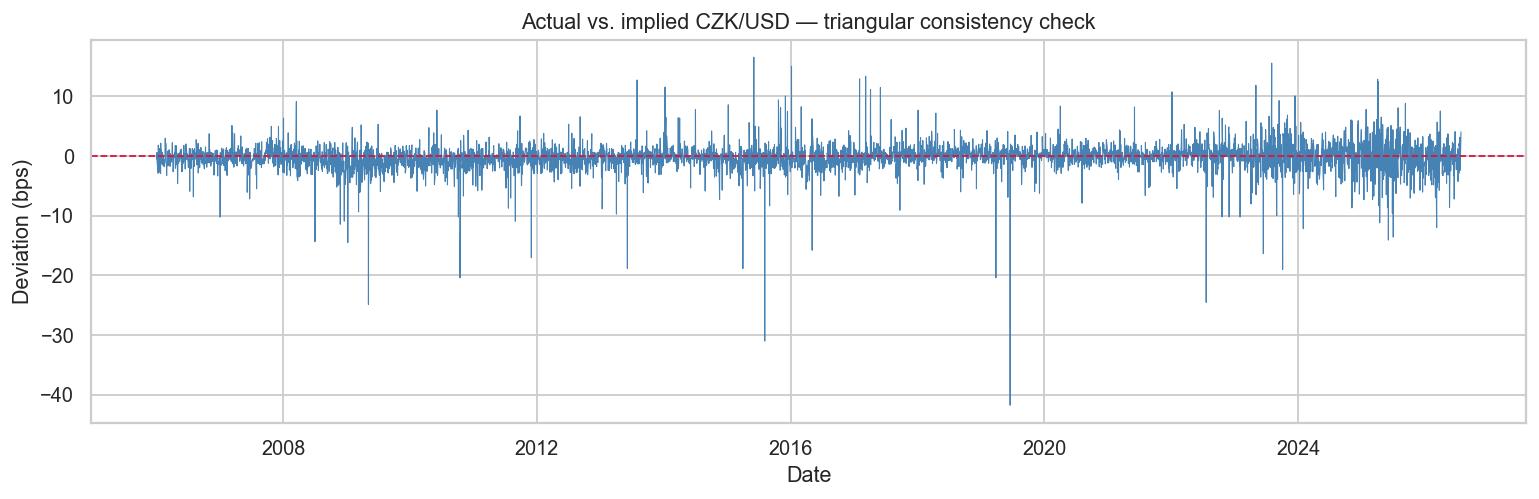

In [3]:
#| label: triangular-consistency
#| fig-cap: "ČNB's quoted CZK/USD vs. the rate implied by CZK/EUR (ČNB) × EUR/USD (ECB), in basis points."
#| code-fold: true

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df['date'], df['deviation_bps'], color='steelblue', linewidth=0.6)
ax.axhline(0, color='crimson', linewidth=1, linestyle='--')
ax.set_ylabel('Deviation (bps)')
ax.set_xlabel('Date')
ax.set_title('Actual vs. implied CZK/USD — triangular consistency check')
plt.tight_layout()
plt.show()


The deviation averages **-0.31 bps** with a standard deviation of **2.4 bps**, and never
exceeds **41.8 bps** in absolute terms across 5,162 trading days — that single largest gap
fell on 2019-06-18, an otherwise unremarkable day, which points to fixing-time noise rather
than a real dislocation. So: no, there is no point in the last 20 years where CZK/USD
diverged meaningfully from what CZK/EUR and EUR/USD implied. The three-currency triangle is
essentially always consistent to a fraction of a percent — exactly what an efficient,
arbitrage-free FX market should look like. That rules out the literal "is the ratio ever
inconsistent" question, but it isn't really the interesting one. The interesting question is
whether CZK/EUR itself moves independently of EUR/USD — i.e. whether the *level* the
triangle is consistent *around* ever shifts for CZK-specific reasons.

## Zooming out: 20 years of levels

Indexing all three series to 100 at the start of the sample makes them comparable regardless
of their different units (CZK/EUR trades around 23–29, CZK/USD around 14–26, EUR/USD
inverted around 0.63–1.04).

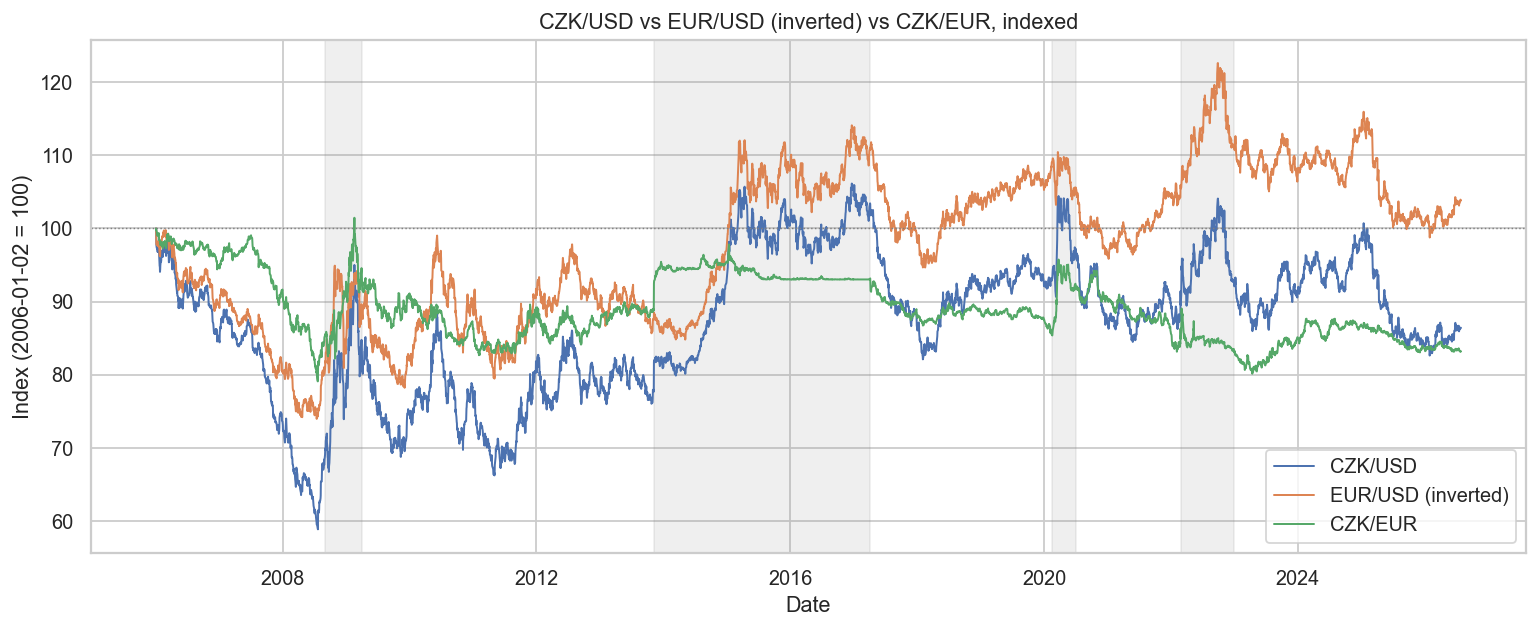

In [4]:
#| label: indexed-levels
#| fig-cap: "CZK/USD, EUR/USD (inverted) and CZK/EUR indexed to 100 at 2006-01-02. Shaded bands mark the four episodes analysed below."
#| code-fold: true

base = df.iloc[0]
idx = pd.DataFrame({'date': df['date']})
for leg, label in [('czk_per_usd', 'CZK/USD'), ('eur_per_usd', 'EUR/USD (inverted)'), ('czk_per_eur', 'CZK/EUR')]:
    idx[label] = df[leg] / base[leg] * 100

fig, ax = plt.subplots(figsize=(12, 5))
for label, color in zip(['CZK/USD', 'EUR/USD (inverted)', 'CZK/EUR'], ['#4c72b0', '#dd8452', '#55a868']):
    ax.plot(idx['date'], idx[label], label=label, color=color, linewidth=1.1)
shade_events(ax)
ax.axhline(100, color='grey', linewidth=0.8, linestyle=':')
ax.set_ylabel('Index (2006-01-02 = 100)')
ax.set_xlabel('Date')
ax.set_title('CZK/USD vs EUR/USD (inverted) vs CZK/EUR, indexed')
ax.legend()
plt.tight_layout()
plt.show()


CZK/EUR (green) is visibly the calmest of the three lines, as expected — but it is not flat.
Some concrete levels (CZK per EUR): **29.05** at the start of 2006, down to **22.97** at its
strongest point (2008-07-21, just before the financial crisis hit), then a sharp reversal to
**29.47** by 2009-02-17 as the crisis pushed capital out of the koruna — a **~28% swing in
seven months**, nothing like a peg. ČNB's floor then pins it dead flat at ~27 from
late 2013 to early 2017 (visible as the flattest stretch of any line in the whole chart), and
since the floor was lifted it has gradually re-appreciated to **24.16** today. CZK/USD and
EUR/USD (inverted), meanwhile, swing over a much wider range and largely move together —
which is exactly the "CZK just rides EUR against the dollar" pattern I expected to find,
*except* during the episodes shaded above, which the next two sections quantify.

## How tight is "tight", actually?

Rather than eyeballing the chart, the standard way to quantify how much a rate is moving is
**realized volatility**: the annualized standard deviation of daily log returns
($\sigma_{daily} \times \sqrt{252}$), computed on a rolling 90-day window so it can change
over time. A currency held on a tight de facto peg should show consistently low volatility;
a floating one should track its economic drivers.

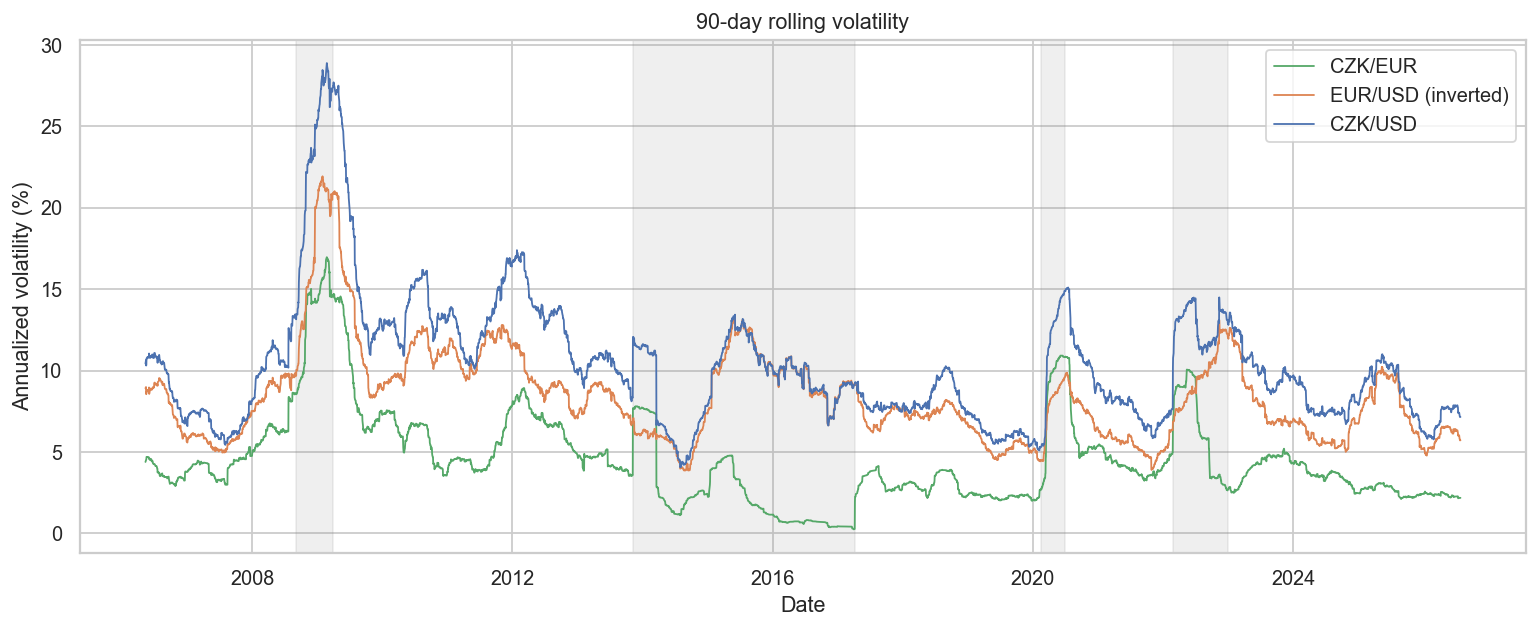

Median annualized vol, full sample:
CZK/EUR               3.90
EUR/USD (inverted)    7.98
CZK/USD               9.83
dtype: float64


In [5]:
#| label: rolling-volatility
#| fig-cap: "90-day rolling annualized volatility of daily log returns."
#| code-fold: true

vol = pd.DataFrame({'date': df['date']})
for leg, label in [('lret_czk_per_eur', 'CZK/EUR'), ('lret_eur_per_usd', 'EUR/USD (inverted)'), ('lret_czk_per_usd', 'CZK/USD')]:
    vol[label] = df[leg].rolling(90).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(12, 5))
for label, color in zip(['CZK/EUR', 'EUR/USD (inverted)', 'CZK/USD'], ['#55a868', '#dd8452', '#4c72b0']):
    ax.plot(vol['date'], vol[label], label=label, color=color, linewidth=1.0)
shade_events(ax)
ax.set_ylabel('Annualized volatility (%)')
ax.set_xlabel('Date')
ax.set_title('90-day rolling volatility')
ax.legend()
plt.tight_layout()
plt.show()

print('Median annualized vol, full sample:')
print((vol[['CZK/EUR', 'EUR/USD (inverted)', 'CZK/USD']].median()).round(2))


Over the full sample, CZK/EUR's median annualized volatility is **3.9%**, less than half
of EUR/USD's **8.0%** — so "CZK/EUR is the calm one" holds up quantitatively, not just
visually. But it is not constant:

- **During the 2013–2017 floor**, CZK/EUR volatility collapses to a median of **1.7%**
  while EUR/USD carries on unaffected at **9.0%** — the floor visibly worked, exactly as
  designed.
- **Right after the floor was lifted** (April 2017), volatility snaps back: within a few
  months it peaks at **3.9%** on 2017-07-31, roughly double the floor-era median, as the
  market re-discovered a market-clearing price for the koruna.
- **In 2022**, CZK/EUR volatility rises to a mean of **6.2%** (peaking at **10.1%**) —
  nearly catching up to EUR/USD's own 9.0% average. The usually-calm leg became almost as
  turbulent as the other two, in the same year ČNB was hiking rates from 3.75% to 7% and
  actively intervening to defend the currency.

## Does CZK/USD actually ride along with EUR/USD?

If CZK just tracks the euro, CZK/USD's day-to-day moves should be highly correlated with
EUR/USD's — most of the variation in "koruna vs. dollar" would really just be "euro vs.
dollar" passing through. A 180-day rolling correlation of daily log returns tests that
directly, and — unlike the volatility chart above — needs a bit of care interpreting during
the floor period, as the commentary below explains.

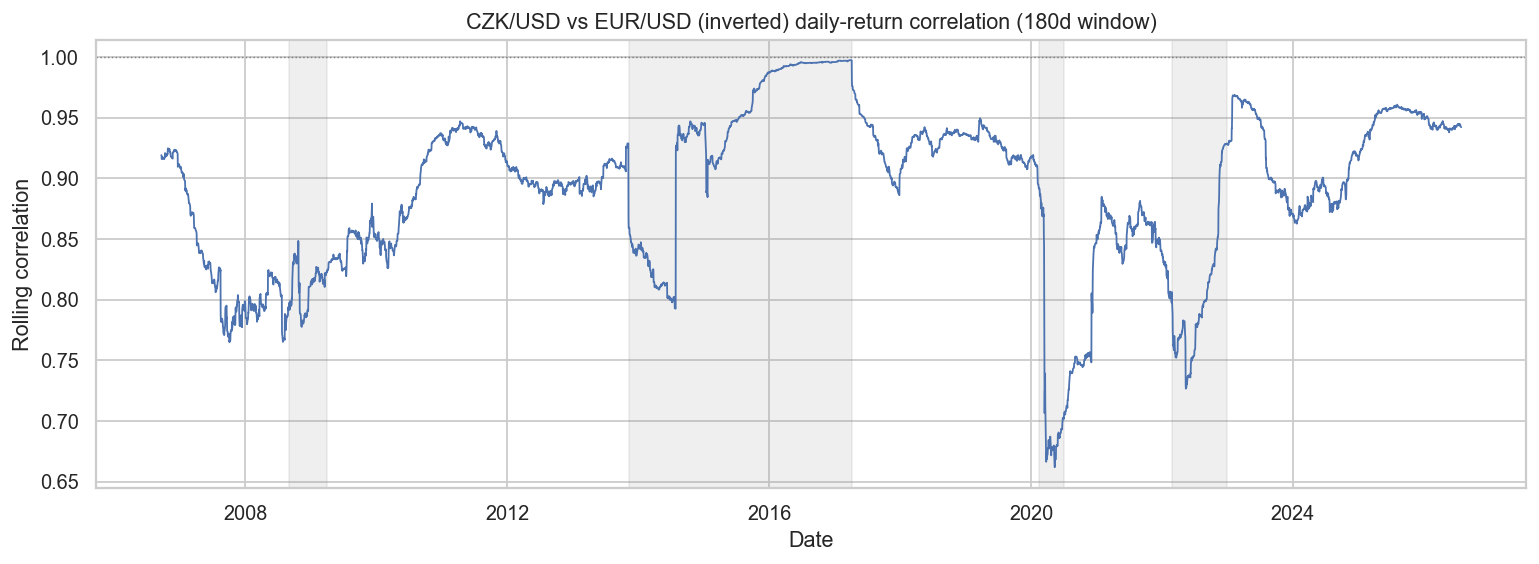

Median full sample: 0.906
Global minimum: 0.662 on 2020-05-11


In [6]:
#| label: rolling-correlation
#| fig-cap: "180-day rolling correlation between CZK/USD and EUR/USD (inverted) daily log returns."
#| code-fold: true

corr = pd.DataFrame({'date': df['date']})
corr['corr'] = df['lret_czk_per_usd'].rolling(180).corr(df['lret_eur_per_usd'])

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(corr['date'], corr['corr'], color='#4c72b0', linewidth=1.0)
shade_events(ax)
ax.axhline(1, color='grey', linewidth=0.8, linestyle=':')
ax.set_ylabel('Rolling correlation')
ax.set_xlabel('Date')
ax.set_title('CZK/USD vs EUR/USD (inverted) daily-return correlation (180d window)')
plt.tight_layout()
plt.show()

print('Median full sample:', round(corr['corr'].median(), 3))
print('Global minimum:', round(corr['corr'].min(), 3), 'on', corr.loc[corr['corr'].idxmin(), 'date'].date())


Median correlation across the full sample is **0.91** — most of the time, CZK/USD really
is largely a pass-through of EUR/USD, supporting the initial prior. Two clear dips stand
out: a sample-wide **minimum of 0.66 on 2020-05-11** (the rolling window centred on the
COVID crash), and a drop to a **2022 mean of 0.81**, both periods where CZK/EUR itself was
independently volatile (previous section).

One counter-intuitive wrinkle: correlation actually goes *up* during the 2013–2017 floor
(mean **0.94**, peaking at **0.997** near the end of the regime) — not down. That makes
sense mechanically: pinning CZK/EUR near-constant turns CZK/USD into an almost perfectly
scaled copy of EUR/USD, so of course the two move together. The floor is the period ČNB was
running the most independent, activist policy of the entire sample, and the correlation
chart alone would suggest the opposite. The real signature of that independence is the
volatility collapse in CZK/EUR itself from the previous section, not this correlation — a
reminder that "high correlation with EUR/USD" and "no independent policy" are not the same
claim.

## Two episodes, side by side

The clearest test is to zoom into the two windows where ČNB was most actively managing the
currency and see what CZK/EUR was doing while EUR/USD did its own thing.

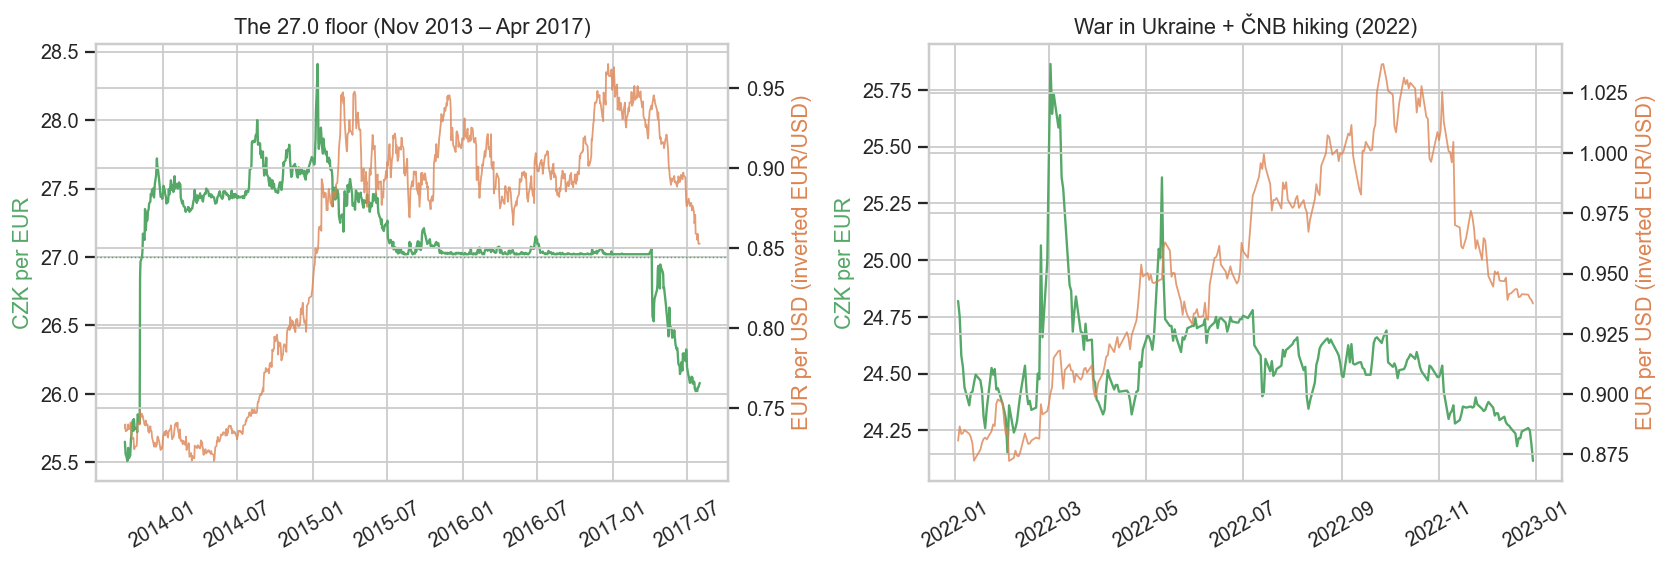

In [7]:
#| label: event-zoom
#| fig-cap: "CZK/EUR (left axis) vs EUR/USD, inverted (right axis) during the two most active-policy episodes."
#| code-fold: true

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

windows = [
    ('2013-10-01', '2017-07-31', 'The 27.0 floor (Nov 2013 – Apr 2017)', axes[0]),
    ('2022-01-01', '2022-12-31', 'War in Ukraine + ČNB hiking (2022)', axes[1]),
]
for start, end, title, ax in windows:
    w = df[(df['date'] >= start) & (df['date'] <= end)]
    ax2 = ax.twinx()
    ax.plot(w['date'], w['czk_per_eur'], color='#55a868', linewidth=1.3, label='CZK/EUR')
    ax2.plot(w['date'], w['eur_per_usd'], color='#dd8452', linewidth=1.0, alpha=0.8, label='EUR/USD (inverted)')
    if start.startswith('2013'):
        ax.axhline(27.0, color='#55a868', linewidth=0.8, linestyle=':')
    ax.set_ylabel('CZK per EUR', color='#55a868')
    ax2.set_ylabel('EUR per USD (inverted EUR/USD)', color='#dd8452')
    ax.set_title(title)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Left (2013–2017):** CZK/EUR (green) sits dead flat at the 27.0 floor for three and a half
years while EUR/USD, inverted (orange), ranges from **0.72 (2014-05-06) to 0.96
(2016-12-20)** — equivalently, the standard EUR/USD quote fell from about **1.39 to 1.04**,
the real-world move driven by ECB QE and negative rates. A ~25% swing in the dollar leg with
essentially zero pass-through into CZK/EUR. This is the cleanest possible counter-example to
"CZK just rides EUR" — ČNB simply didn't let it.

**Right (2022):** EUR/USD, inverted, rose from **0.881 on 2022-01-03 to a high of 1.037 on
2022-09-27** — equivalently, the standard EUR/USD quote fell from **1.1355 to 0.9644**,
briefly touching parity, driven by the energy shock and Fed tightening. CZK/EUR, by
contrast, stayed inside a **24.12–25.87** band the entire year (a ~7% range, and most of
that was a brief spike right after the invasion that receded within weeks). If CZK/EUR had
simply floated with the broader risk-off move the way EUR/USD did, it would have moved much
more than it did — the relative stability took active ČNB FX intervention and rate hikes
(3.75% → 7% that year) to hold. It shows up in the data as *reduced* return correlation and
*elevated* CZK/EUR volatility (previous two sections), even though the year-over-year level
barely moved — the koruna was independently active, just aimed at staying still rather than
moving.

## Summary

Going back to the original question — does having its own currency actually let Czechia
run different monetary policy, or is CZK/EUR effectively pegged to the point that CZK/USD
is just EUR/USD in disguise?

- **The three rates are always mutually consistent.** No triangular arbitrage gap worth
  mentioning ever appears (max 41.8 bps in 20 years, essentially fixing-time noise). This
  part of the prior was right — the FX market enforces the triangle relentlessly.
- **But CZK/EUR is not a peg.** It has swung as much as ~28% in seven months (2008–09) and
  moved from 29.05 to a low of 22.97 to a floor at 27.0 and back down to 24.16, all within
  the sample. It's calmer than EUR/USD on average (median annualized vol 3.9% vs 8.0%), not
  static.
- **The 2013–2017 floor is the clearest evidence of independent policy**: CZK/EUR volatility
  collapsed to a fraction of its usual level while EUR/USD carried on unaffected, and it
  snapped back within months of the floor being lifted.
- **2022 is the clearest evidence in returns**: correlation between CZK/USD and EUR/USD
  dropped to its second-lowest level of the whole sample (mean 0.81) exactly while ČNB was
  hiking hardest and defending the currency — even though the *level* of CZK/EUR barely
  moved, which took active intervention, not passive tracking.
- **COVID (2020) shows the same pattern on the downside**: the sample's single lowest
  correlation reading (0.66) falls right in the COVID window, alongside an ~11% koruna
  depreciation against the euro in about five weeks that had no EUR/USD counterpart of that
  size.

So the original skepticism was partly right (day to day, CZK/USD mostly is a pass-through of
EUR/USD) and partly wrong (in the specific episodes where it mattered — 2008–09, the 2013–17
floor, 2020, and 2022 — CZK/EUR moved on its own terms, sometimes by a lot). Owning the
koruna gave ČNB a lever it visibly used more than once; it just isn't visible on an average
day, only in the tails.

::: {.callout-tip collapse="true"}
## Generated with Claude Code
This analysis was developed with the help of [Claude Code](https://claude.ai/claude-code).
:::